# LAB 07 – Processamento em Lote e Segmentação de Frutas Vermelhas no Espaço HSV


## 1. Importações e configurações

In [1]:
import os
import glob
import json
import zipfile

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DIR_ENTRADA = "/content/entrada"
DIR_SAIDA   = "/output"
TAMANHO     = (512, 512)


FAIXA1_INF = np.array([0,   50, 50], dtype=np.uint8)
FAIXA1_SUP = np.array([10, 255, 255], dtype=np.uint8)
FAIXA2_INF = np.array([170, 50, 50], dtype=np.uint8)
FAIXA2_SUP = np.array([180, 255, 255], dtype=np.uint8)

KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

os.makedirs(DIR_ENTRADA, exist_ok=True)
os.makedirs(DIR_SAIDA, exist_ok=True)
print("OpenCV:", cv2.__version__)

OpenCV: 4.14.0


## 2. Obtenção das imagens
Execute a célula abaixo e **selecione as 10 imagens** `.jpg` (ou um `.zip` com elas).
Se preferir usar o Google Drive, veja a célula opcional logo depois.

In [2]:
try:
    from google.colab import files
    enviados = files.upload()
    for nome, conteudo in enviados.items():
        caminho = os.path.join(DIR_ENTRADA, nome)
        with open(caminho, "wb") as f:
            f.write(conteudo)
        if nome.lower().endswith(".zip"):
            with zipfile.ZipFile(caminho) as z:
                z.extractall(DIR_ENTRADA)
except ImportError:
    print("Fora do Colab: coloque as imagens manualmente em", DIR_ENTRADA)

Saving a86e1ae5715d3f92df2cccfbd60d29d0.jpg to a86e1ae5715d3f92df2cccfbd60d29d0.jpg
Saving framboesa.jpg to framboesa.jpg
Saving istockphoto-533381303-612x612.jpg to istockphoto-533381303-612x612.jpg
Saving istockphoto-1125584344-612x612.jpg to istockphoto-1125584344-612x612.jpg
Saving pngtree-fresh-apple-fruit-red-jpg-image_10203073.png to pngtree-fresh-apple-fruit-red-jpg-image_10203073.png


In [4]:
GERAR_DEMO = False

if GERAR_DEMO:
    rng = np.random.default_rng(42)
    for i in range(1, 11):
        h, w = int(rng.integers(300, 900)), int(rng.integers(300, 900))
        fundo = np.full((h, w, 3), (60, 140, 60), np.uint8)       # fundo verde (BGR)
        fundo = cv2.add(fundo, rng.integers(0, 30, fundo.shape, dtype=np.uint8))
        cx, cy = int(rng.integers(w*0.3, w*0.7)), int(rng.integers(h*0.3, h*0.7))
        r = int(min(h, w) * rng.uniform(0.12, 0.25))
        cv2.circle(fundo, (cx, cy), r, (30, 30, 200), -1)          # "fruta" vermelha
        cv2.imwrite(os.path.join(DIR_ENTRADA, f"fruta_{i:02d}.jpg"), fundo)
    print("Imagens de demonstração geradas.")

## 3. Funções do pipeline

In [5]:
def listar_imagens(diretorio):
    """Retorna a lista ordenada de arquivos .jpg/.jpeg do diretório (recursivo)."""
    padroes = ("*.jpg", "*.jpeg", "*.JPG", "*.JPEG")
    arquivos = set()
    for p in padroes:
        arquivos.update(glob.glob(os.path.join(diretorio, "**", p), recursive=True))
    return sorted(arquivos)


def carregar_imagem(caminho):
    """Lê a imagem (BGR) e verifica a integridade da leitura. Retorna None em caso de falha."""
    img = cv2.imread(caminho, cv2.IMREAD_COLOR)
    if img is None or img.size == 0:
        print(f"[ERRO] Falha ao ler/arquivo corrompido: {caminho}")
        return None
    return img


def redimensionar(img, tamanho=TAMANHO):
    """Redimensiona para 512x512. INTER_AREA para redução, INTER_LINEAR para ampliação."""
    h, w = img.shape[:2]
    reduzindo = (w * h) > (tamanho[0] * tamanho[1])
    interp = cv2.INTER_AREA if reduzindo else cv2.INTER_LINEAR
    return cv2.resize(img, tamanho, interpolation=interp)


def bgr_para_hsv(img_bgr):
    """Converte BGR -> HSV."""
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)


def segmentar_vermelho(img_hsv):
    """
    Segmenta a cor vermelha combinando duas máscaras (extremos da escala Hue)
    por meio de disjunção lógica. Retorna máscara binária uint8 (0/255).
    """
    mascara1 = cv2.inRange(img_hsv, FAIXA1_INF, FAIXA1_SUP)   # vermelho-baixo
    mascara2 = cv2.inRange(img_hsv, FAIXA2_INF, FAIXA2_SUP)   # vermelho-alto
    return cv2.bitwise_or(mascara1, mascara2)


def refinar_mascara(mascara):
    """Abertura (remove ruído) seguida de fechamento (preenche lacunas) e binarização final."""
    m = cv2.morphologyEx(mascara, cv2.MORPH_OPEN,  KERNEL, iterations=1)
    m = cv2.morphologyEx(m,       cv2.MORPH_CLOSE, KERNEL, iterations=2)
    _, m = cv2.threshold(m, 127, 255, cv2.THRESH_BINARY)       # garante apenas 0 e 255
    return m


def extrair_metricas(mascara):
    """
    Encontra o contorno de maior área e retorna:
      bbox = (x, y, w, h) e centroide = (cx, cy) via cv2.moments.
    Retorna (None, None, None) se nenhuma região for encontrada.
    """
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contornos:
        return None, None, None
    maior = max(contornos, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(maior)
    M = cv2.moments(maior)
    if M["m00"] == 0:                       # região degenerada
        cx, cy = x + w / 2, y + h / 2
    else:
        cx, cy = M["m10"] / M["m00"], M["m01"] / M["m00"]
    return (x, y, w, h), (cx, cy), maior


def desenhar_resultado(img_bgr, bbox, centroide):
    """Desenha a caixa delimitadora e o centroide sobre uma cópia da imagem."""
    saida = img_bgr.copy()
    if bbox is not None:
        x, y, w, h = bbox
        cv2.rectangle(saida, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.circle(saida, (int(round(centroide[0])), int(round(centroide[1]))), 5, (255, 0, 0), -1)
        cv2.putText(saida, f"({centroide[0]:.0f},{centroide[1]:.0f})",
                    (x, max(y - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return saida

## 4. Execução do processamento em lote

In [6]:
arquivos = listar_imagens(DIR_ENTRADA)
print(f"{len(arquivos)} imagem(ns) encontrada(s).")
if len(arquivos) != 10:
    print("ATENÇÃO: o enunciado prevê 10 imagens. Verifique o diretório de entrada.")

resultados = []
visualizacao = []

for caminho in arquivos:
    nome = os.path.basename(caminho)
    base = os.path.splitext(nome)[0]

    img = carregar_imagem(caminho)
    if img is None:
        continue

    img_512 = redimensionar(img)

    hsv = bgr_para_hsv(img_512)

    mascara = segmentar_vermelho(hsv)

    binaria = refinar_mascara(mascara)

    bbox, centroide, _ = extrair_metricas(binaria)
    img_bbox = desenhar_resultado(img_512, bbox, centroide)

    cv2.imwrite(os.path.join(DIR_SAIDA, f"{base}_binaria.png"), binaria)
    cv2.imwrite(os.path.join(DIR_SAIDA, f"{base}_bbox.png"), img_bbox)

    if bbox is None:
        print(f"[AVISO] Nenhuma região vermelha detectada em {nome}")
        resultados.append({"imagem": nome, "x": None, "y": None, "w": None, "h": None,
                           "centroide_x": None, "centroide_y": None})
    else:
        x, y, w, h = bbox
        resultados.append({"imagem": nome, "x": x, "y": y, "w": w, "h": h,
                           "centroide_x": round(centroide[0], 2),
                           "centroide_y": round(centroide[1], 2)})
        print(f"{nome}: bbox=({x}, {y}, {w}, {h})  centroide=({centroide[0]:.2f}, {centroide[1]:.2f})")

    visualizacao.append((nome, img_512, binaria, img_bbox))

4 imagem(ns) encontrada(s).
ATENÇÃO: o enunciado prevê 10 imagens. Verifique o diretório de entrada.
a86e1ae5715d3f92df2cccfbd60d29d0.jpg: bbox=(8, 99, 498, 413)  centroide=(256.35, 276.29)
framboesa.jpg: bbox=(38, 154, 397, 285)  centroide=(242.10, 323.07)
istockphoto-1125584344-612x612.jpg: bbox=(52, 120, 409, 315)  centroide=(255.74, 252.26)
istockphoto-533381303-612x612.jpg: bbox=(144, 188, 311, 284)  centroide=(304.76, 335.43)


## 5. Exportação dos dados (CSV e JSON)

In [7]:
df = pd.DataFrame(resultados)
df.to_csv(os.path.join(DIR_SAIDA, "resultados_lote.csv"), index=False)
with open(os.path.join(DIR_SAIDA, "resultados_lote.json"), "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

print("Arquivos salvos em", DIR_SAIDA)
df

Arquivos salvos em /output


,imagem,x,y,w,h,centroide_x,centroide_y
0,a86e1ae5715d3f92df2cccfbd60d29d0.jpg,8,99,498,413,256.35,276.29
1,framboesa.jpg,38,154,397,285,242.10,323.07
2,istockphoto-1125584344-612x612.jpg,52,120,409,315,255.74,252.26
3,istockphoto-533381303-612x612.jpg,144,188,311,284,304.76,335.43


## 6. Visualização dos resultados

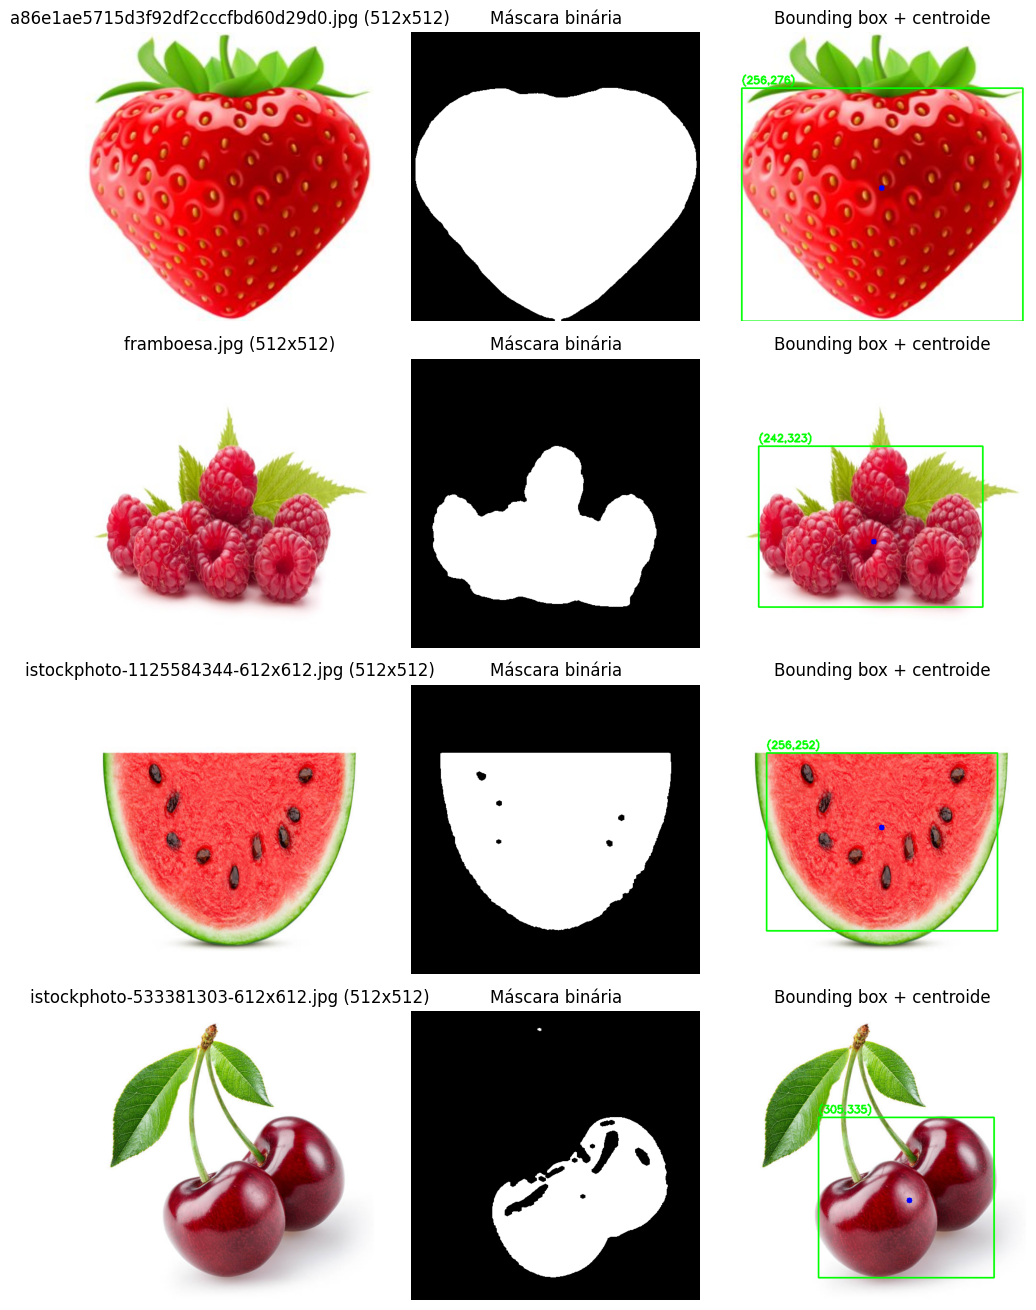

In [8]:
n = len(visualizacao)
if n:
    fig, eixos = plt.subplots(n, 3, figsize=(10, 3.3 * n))
    eixos = np.atleast_2d(eixos)
    for i, (nome, img_512, binaria, img_bbox) in enumerate(visualizacao):
        eixos[i, 0].imshow(cv2.cvtColor(img_512, cv2.COLOR_BGR2RGB)); eixos[i, 0].set_title(f"{nome} (512x512)")
        eixos[i, 1].imshow(binaria, cmap="gray");                    eixos[i, 1].set_title("Máscara binária")
        eixos[i, 2].imshow(cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB)); eixos[i, 2].set_title("Bounding box + centroide")
        for ax in eixos[i]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()

## 7. Compactar e baixar todos os resultados

In [9]:
import shutil
shutil.make_archive("/content/resultados_lote", "zip", DIR_SAIDA)
try:
    from google.colab import files
    files.download("/content/resultados_lote.zip")
except ImportError:
    print("ZIP criado em /content/resultados_lote.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>